<a href="https://colab.research.google.com/github/Abhinraj175/trial/blob/main/Malaysia_Flood_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install geopandas rasterio rasterstats pandas


In [ ]:
# ====================================================
# TASK 1(a):
# ====================================================
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import pandas as pd

state_shp = "/content/drive/MyDrive/Abhinraj/AON Task/gadm41_MYS_1.shp"
population_raster = "/content/drive/MyDrive/Abhinraj/AON Task/mys_pop_2022_CN_100m_R2025A_v1.tif"

# Read state boundaries
states = gpd.read_file(state_shp)

# Open raster properly
with rasterio.open(population_raster) as src:
    raster_crs = src.crs
    raster_nodata = src.nodata

print("Raster NoData value:", raster_nodata)

# Reproject states to raster CRS
states = states.to_crs(raster_crs)

# Zonal statistics (MATCH QGIS DEFAULT)
stats = zonal_stats(
    vectors=states,
    raster=population_raster,
    stats=["sum"],
    nodata=raster_nodata,   # ✅ CORRECT
    all_touched=False       # QGIS default behaviour
)

# Attach results
states["Total_Population"] = [s["sum"] for s in stats]
states["Total_Population"] = states["Total_Population"].fillna(0).astype(int)

# Final table
population_table = states[["NAME_1", "Total_Population"]]
population_table.columns = ["State", "Total_Population"]

print(population_table)
population_table.to_csv("Malaysia_State_Population.csv", index=False)
# SAVE TO SAME BASE DIRECTORY
output_path = "/content/drive/MyDrive/Abhinraj/AON Task/Malaysia_State_Population.csv"
population_table.to_csv(output_path, index=False)

print("CSV saved to:", output_path)


Raster NoData value: -99999.0
              State  Total_Population
0             Johor           4226864
1             Kedah           2248900
2          Kelantan           1914062
3      Kuala Lumpur           2275946
4            Labuan            101964
5            Melaka           1051033
6   Negeri Sembilan           1277112
7            Pahang           1689585
8             Perak           2635410
9            Perlis            301672
10     Pulau Pinang           1821777
11        Putrajaya            101129
12            Sabah           3701403
13          Sarawak           2596478
14         Selangor           7250621
15        Trengganu           1246698
CSV saved to: /content/drive/MyDrive/Abhinraj/AON Task/Malaysia_State_Population.csv


In [ ]:
# ====================================================
# TASK 1(b):
# ====================================================
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import pandas as pd
import numpy as np

# ---------------------------------
# File paths
# ---------------------------------
admin2_shp = "/content/drive/MyDrive/Abhinraj/AON Task/gadm41_MYS_2.shp"
population_raster = "/content/drive/MyDrive/Abhinraj/AON Task/mys_pop_2022_CN_100m_R2025A_v1.tif"

# ---------------------------------
# Read Admin-2 boundaries
# ---------------------------------
districts = gpd.read_file(admin2_shp)

# ---------------------------------
# Filter Selangor districts
# ---------------------------------
selangor_districts = districts[districts["NAME_1"] == "Selangor"].copy()

# ---------------------------------
# Open raster and read metadata
# ---------------------------------
with rasterio.open(population_raster) as src:
    raster_crs = src.crs
    raster_nodata = src.nodata

print("Raster CRS:", raster_crs)
print("Raster NoData value:", raster_nodata)

# ---------------------------------
# Reproject districts to raster CRS
# ---------------------------------
selangor_districts = selangor_districts.to_crs(raster_crs)

# ---------------------------------
# Zonal statistics (QGIS-equivalent)
# ---------------------------------
stats = zonal_stats(
    vectors=selangor_districts,
    raster=population_raster,
    stats=["sum"],
    nodata=raster_nodata,
    all_touched=False   # matches QGIS default
)

# ---------------------------------
# Attach population values
# ---------------------------------
selangor_districts["Total_Population"] = [s["sum"] for s in stats]
selangor_districts["Total_Population"] = (
    selangor_districts["Total_Population"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------
# Create population bands (Quantiles)
# ---------------------------------
# 3 bands: Low / Medium / High
selangor_districts["Population_Band"] = pd.qcut(
    selangor_districts["Total_Population"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# ---------------------------------
# Final output table
# ---------------------------------
output_table = selangor_districts[
    ["NAME_2", "Total_Population", "Population_Band"]
].rename(columns={"NAME_2": "District"})

print(output_table)

# ---------------------------------
# Save results
# ---------------------------------
output_table.to_csv("/content/drive/MyDrive/Abhinraj/AON Task/Selangor_District_Population_Bands.csv", index=False)


Raster CRS: EPSG:4326
Raster NoData value: -99999.0
           District  Total_Population Population_Band
128          Gombak           1051543          Medium
129     Hulu Langat           1494534            High
130   Hulu Selangor            262302             Low
131           Klang           1164080            High
132    Kuala Langat            320499          Medium
133  Kuala Selangor            308224             Low
134        Petaling           2175429            High
135    Sabak Bernam            113089             Low
136          Sepang            360916          Medium


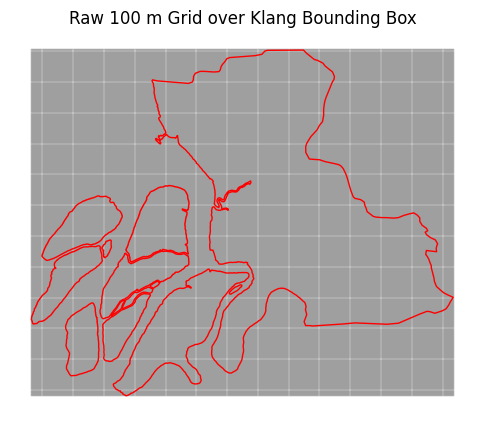

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Klang_Raw_100m_Grid.png


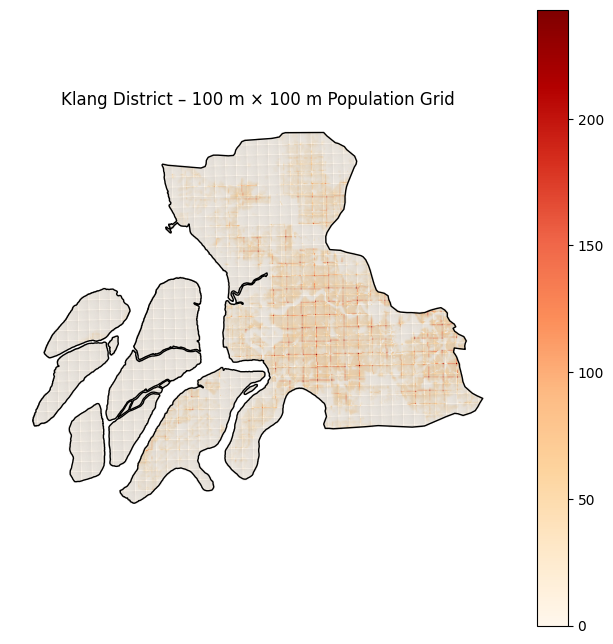

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Klang_100m_Population_Grid_Map.png
Total population in Klang: 1144425
Outputs saved in: /content/drive/MyDrive/Abhinraj/AON Task/


In [ ]:
# ====================================================
# TASK 1(c): 100 m x 100 m population grid for Klang
# ====================================================

import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterstats import zonal_stats
from shapely.geometry import box
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# ----------------------------------------------------
# Base output directory (IMPORTANT CHANGE)
# ----------------------------------------------------
base_dir = "/content/drive/MyDrive/Abhinraj/AON Task/"

# Ensure directory exists
os.makedirs(base_dir, exist_ok=True)

# ----------------------------------------------------
# File paths
# ----------------------------------------------------
district_shp = base_dir + "gadm41_MYS_2.shp"
population_raster = base_dir + "mys_pop_2022_CN_100m_R2025A_v1.tif"

cropped_raster = base_dir + "klang_population_crop.tif"
output_gpkg = base_dir + "Klang_100m_Population_Grid.gpkg"
output_csv = base_dir + "Klang_100m_Population_Grid.csv"

# ----------------------------------------------------
# Read district shapefile & extract Klang
# ----------------------------------------------------
districts = gpd.read_file(district_shp)

klang = districts[
    (districts["NAME_1"] == "Selangor") &
    (districts["NAME_2"] == "Klang")
].copy()

# ----------------------------------------------------
# Reproject Klang to metric CRS (UTM Zone 47N)
# ----------------------------------------------------
klang = klang.to_crs(epsg=32647)

# ----------------------------------------------------
# Create 100 m × 100 m uniform grid
# ----------------------------------------------------
xmin, ymin, xmax, ymax = klang.total_bounds
grid_size = 100  # meters

grid_polygons = []
grid_ids = []
gid = 0

for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        grid_polygons.append(box(x, y, x + grid_size, y + grid_size))
        grid_ids.append(gid)
        gid += 1

grid = gpd.GeoDataFrame(
    {"Grid_ID": grid_ids},
    geometry=grid_polygons,
    crs=klang.crs
)

# ----------------------------------------------------
# QC 1: Raw grid map (Show + Save Once)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
grid.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.2)
klang.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

ax.set_title("Raw 100 m Grid over Klang Bounding Box")
ax.set_axis_off()

raw_grid_map_path = os.path.join(base_dir, "Klang_Raw_100m_Grid.png")
plt.savefig(raw_grid_map_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

print("Saved:", raw_grid_map_path)


# ----------------------------------------------------
# Retain grid cells intersecting Klang
# ----------------------------------------------------
klang_geom = klang.geometry.iloc[0]
grid_klang = grid[grid.intersects(klang_geom)].copy()
grid_klang.reset_index(drop=True, inplace=True)

# ----------------------------------------------------
# Crop population raster to Klang extent (PERFORMANCE FIX)
# ----------------------------------------------------
with rasterio.open(population_raster) as src:
    klang_geom_raster = klang.to_crs(src.crs).geometry
    geoms = [json.loads(klang_geom_raster.to_json())["features"][0]["geometry"]]

    pop_crop, pop_transform = mask(
        src,
        geoms,
        crop=True,
        nodata=src.nodata
    )

    pop_meta = src.meta.copy()

pop_meta.update({
    "height": pop_crop.shape[1],
    "width": pop_crop.shape[2],
    "transform": pop_transform
})

# Save cropped raster
with rasterio.open(cropped_raster, "w", **pop_meta) as dst:
    dst.write(pop_crop)

# ----------------------------------------------------
# Reproject grid to raster CRS
# ----------------------------------------------------
grid_klang = grid_klang.to_crs(pop_meta["crs"])

# ----------------------------------------------------
# Zonal statistics: population per grid cell
# ----------------------------------------------------
stats = zonal_stats(
    vectors=grid_klang,
    raster=cropped_raster,
    stats=["sum"],
    nodata=pop_meta["nodata"],
    all_touched=False
)

grid_klang["Population"] = [s["sum"] for s in stats]
grid_klang["Population"] = grid_klang["Population"].fillna(0).astype(int)

# ----------------------------------------------------
# QC 2: Final population grid (Show + Save Once)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

grid_klang.plot(
    column="Population",
    ax=ax,
    cmap="OrRd",
    legend=True,
    linewidth=0.05,
    edgecolor="grey"
)

klang.to_crs(grid_klang.crs).boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1
)

ax.set_title("Klang District – 100 m × 100 m Population Grid")
ax.set_axis_off()

final_grid_map_path = os.path.join(base_dir, "Klang_100m_Population_Grid_Map.png")
plt.savefig(final_grid_map_path, dpi=350, bbox_inches="tight", pad_inches=0.1)
plt.show()

print("Saved:", final_grid_map_path)

# ----------------------------------------------------
# Save outputs (ALL in Malaysia folder)
# ----------------------------------------------------
grid_klang.to_file(output_gpkg, driver="GPKG")
grid_klang.drop(columns="geometry").to_csv(output_csv, index=False)

# ----------------------------------------------------
# Final sanity check
# ----------------------------------------------------
print("Total population in Klang:", grid_klang["Population"].sum())
print("Outputs saved in:", base_dir)


✔ Flood raster clipped to Malaysia
✔ Negative/nodata population corrected to 0
✔ Population inside permanent water set to 0
✔ Affected population raster created
✔ State-wise flood affected population calculated
   State_or_Federal_Territory  Flood_Affected_Population
0                       Johor                      12781
1                       Kedah                       1156
2                    Kelantan                        260
3                Kuala Lumpur                      12367
4                      Labuan                        442
5                      Melaka                       1171
6             Negeri Sembilan                       1351
7                      Pahang                       1461
8                       Perak                       1536
9                      Perlis                        101
10               Pulau Pinang                       4620
11                  Putrajaya                        649
12                      Sabah                   

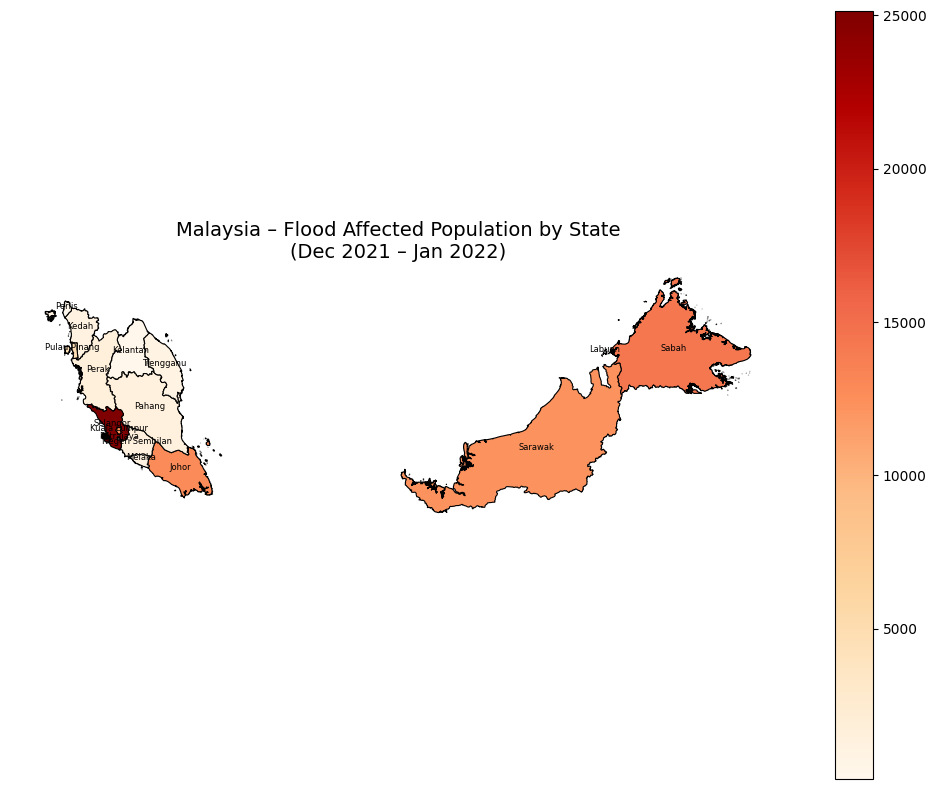

✔ Choropleth saved at: /content/drive/MyDrive/Abhinraj/AON Task/Malaysia_State_Flood_Impact_Map.png


In [ ]:
# Task 2 ==========================================================
# MALAYSIA FLOOD IMPACT (FINAL FIXED VERSION)
# Steps:
# 1) Clip flood raster
# 2) Zero population inside permanent water
# 3) Fix negative / nodata population values
# 4) Flood × Population = Affected population raster
# 5) Sum by State / Federal Territory
# ==========================================================

import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from rasterstats import zonal_stats
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# PATHS
# ----------------------------------------------------------
base = "/content/drive/MyDrive/Abhinraj/AON Task/"

flood_raster = base + "malaysia_flood_extent_20211214_20220114.tif"   # 100 m flood raster (0/1)
population_raster = base + "mys_pop_2022_CN_100m_R2025A_v1.tif"       # 100 m WorldPop
states_shp = base + "gadm41_MYS_1.shp"                                # Admin-1 Malaysia
water_shp = base + "hotosm_mys_waterways_polygons_shp.shp"            # Permanent water polygons

# Outputs
clipped_flood = base + "flood_clipped_malaysia.tif"
clean_population = base + "population_without_water.tif"
affected_pop_raster = base + "affected_population.tif"
final_csv = base + "statewise_flood_affected_population.csv"


# ----------------------------------------------------------
# 1 CLIP FLOOD RASTER TO MALAYSIA
# ----------------------------------------------------------
states = gpd.read_file(states_shp)

with rasterio.open(flood_raster) as src:
    states_clip = states.to_crs(src.crs)
    geoms = [geom.__geo_interface__ for geom in states_clip.geometry]

    flood_clip, transform = mask(src, geoms, crop=True, nodata=0)
    flood_clip = np.squeeze(flood_clip)

    flood_meta = src.meta.copy()
    flood_meta.update({
        "height": flood_clip.shape[-2],
        "width": flood_clip.shape[-1],
        "transform": transform,
        "count": 1
    })

with rasterio.open(clipped_flood, "w", **flood_meta) as dst:
    dst.write(flood_clip.astype(flood_meta["dtype"]), 1)

print("✔ Flood raster clipped to Malaysia")


# ----------------------------------------------------------
# 2 REPROJECT POPULATION TO MATCH FLOOD GRID
# ----------------------------------------------------------
with rasterio.open(clipped_flood) as f_src:
    target_meta = f_src.meta.copy()
    target_transform = f_src.transform

with rasterio.open(population_raster) as pop_src:

    pop_reprojected_data = np.empty(
        (target_meta["height"], target_meta["width"]),
        dtype="float32"
    )

    reproject(
        source=rasterio.band(pop_src, 1),
        destination=pop_reprojected_data,
        src_transform=pop_src.transform,
        src_crs=pop_src.crs,
        dst_transform=target_transform,
        dst_crs=target_meta["crs"],
        resampling=Resampling.nearest,
        src_nodata=pop_src.nodata,
        dst_nodata=0
    )

# ----------------------------------------------------------
# 3 FIX NEGATIVE / NODATA POPULATION VALUES
# ----------------------------------------------------------
pop_reprojected_data = np.where(
    (pop_reprojected_data <= 0) | np.isnan(pop_reprojected_data),
    0,
    pop_reprojected_data
)

print("✔ Negative/nodata population corrected to 0")


# ----------------------------------------------------------
# 4 ZERO POPULATION INSIDE PERMANENT WATER
# ----------------------------------------------------------
water = gpd.read_file(water_shp).to_crs(target_meta["crs"])

water_mask = rasterize(
    [(geom, 1) for geom in water.geometry],
    out_shape=(target_meta["height"], target_meta["width"]),
    transform=target_meta["transform"],
    fill=0,
    dtype="uint8"
)

pop_clean_arr = np.where(water_mask == 1, 0, pop_reprojected_data)

pop_meta = target_meta.copy()
pop_meta.update(dtype="float32", nodata=0)

with rasterio.open(clean_population, "w", **pop_meta) as dst:
    dst.write(pop_clean_arr.astype("float32"), 1)

print("✔ Population inside permanent water set to 0")


# ----------------------------------------------------------
# 5 FLOOD × POPULATION → AFFECTED POPULATION RASTER
# ----------------------------------------------------------
with rasterio.open(clipped_flood) as f_src:
    flood_data = f_src.read(1)

# Ensure flood is clean binary
flood_data = np.where(flood_data == 1, 1, 0).astype("uint8")

affected_pop = np.where(flood_data == 1, pop_clean_arr, 0)
affected_pop = np.where(affected_pop < 0, 0, affected_pop)

affected_meta = pop_meta.copy()

with rasterio.open(affected_pop_raster, "w", **affected_meta) as dst:
    dst.write(affected_pop.astype("float32"), 1)

print("✔ Affected population raster created")


# ----------------------------------------------------------
# 6 POPULATION SUMMARY BY STATE / FEDERAL TERRITORY
# ----------------------------------------------------------
states_final = states_clip

stats = zonal_stats(
    states_final,
    affected_pop_raster,
    stats=["sum"],
    nodata=0
)

states_final["Flood_Affected_Population"] = [
    int(s["sum"]) if s["sum"] is not None else 0
    for s in stats
]

result = states_final[["NAME_1", "Flood_Affected_Population"]]
result.columns = ["State_or_Federal_Territory", "Flood_Affected_Population"]

result.to_csv(final_csv, index=False)

print("✔ State-wise flood affected population calculated")
print(result)
# ==========================================================
# 7 CHOROPLETH MAP – FLOOD AFFECTED POPULATION BY STATE
# ==========================================================
import matplotlib.pyplot as plt

print("✔ Preparing State Impact Choropleth Map...")

impact_csv = final_csv
output_map = base + "Malaysia_State_Flood_Impact_Map.png"

# Load Admin-1 again safely
states_plot = gpd.read_file(states_shp).to_crs(states_clip.crs)

# Load the summary table
impact = pd.read_csv(impact_csv)
impact.columns = ["State_or_Federal_Territory", "Flood_Affected_Population"]

# Merge
states_plot = states_plot.merge(
    impact,
    left_on="NAME_1",
    right_on="State_or_Federal_Territory",
    how="left"
)

states_plot["Flood_Affected_Population"] = (
    states_plot["Flood_Affected_Population"].fillna(0)
)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(10, 8))

states_plot.plot(
    column="Flood_Affected_Population",
    cmap="OrRd",       # Light → Dark red
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Malaysia – Flood Affected Population by State\n(Dec 2021 – Jan 2022)",
    fontsize=14
)
ax.axis("off")

# Label states (optional but helpful)
for idx, row in states_plot.iterrows():
    try:
        ax.annotate(
            text=row["NAME_1"],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=6,
            ha="center"
        )
    except:
        pass

plt.tight_layout()

# Save + Show
plt.savefig(output_map, dpi=350, bbox_inches="tight")
plt.show()

print("✔ Choropleth saved at:", output_map)


In [ ]:
# ==========================================================
# TASK 3(a) — POPULATION WEIGHTED EXPOSURE RASTER
# ==========================================================
# Input:
#  Admin1 shapefile
#  Population Raster (aligned to Malaysia grid)
#  CSV of Exposure by State (MYR)
#
# Output:
#  Exposure raster distributed proportionally to population
# ==========================================================

import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterstats import zonal_stats

# ------------------------------
# PATHS
# ------------------------------
base = "/content/drive/MyDrive/Abhinraj/AON Task/"

states_shp = base + "gadm41_MYS_1.shp"
population_raster = base + "population_without_water.tif"     # from Task 2
exposure_csv = base + "statewise_exposure_MYR.csv"

output_exposure_raster = base + "population_weighted_exposure.tif"
output_table = base + "exposure_check_statewise_sum.csv"

# ------------------------------
# READ INPUTS
# ------------------------------
states = gpd.read_file(states_shp)
states = states[['NAME_1','geometry']].copy()

print("Admin polygons loaded:", len(states))
print(states["NAME_1"].tolist())

exposure_df = pd.read_csv(exposure_csv)


# --- FIX START: Convert Exposure_MYR to numeric type ---
# Remove commas and convert to float
exposure_df["Exposure_MYR"] = (
    exposure_df["Exposure_MYR"]
    .str.replace(",", "")
    .astype(float)
)
# --- FIX END ---

# Merge exposure values into shapefile
# ---- CLEAN TEXT KEYS ----
states["NAME_1"] = states["NAME_1"].str.strip()
exposure_df["NAME_1"] = exposure_df["NAME_1"].str.strip()

# ---- SAFETY CHECK ----
print("Unique shapefile names:", states["NAME_1"].nunique())
print("Unique CSV names:", exposure_df["NAME_1"].nunique())

# ---- VALIDATE: must be 1:1 ----
states = states.merge(
    exposure_df[["NAME_1","Exposure_MYR"]],
    on="NAME_1",
    how="left",
    validate="1:1"    # will THROW ERROR if mismatch
)

print("After merge rows:", len(states))
print(states[["NAME_1","Exposure_MYR"]])


print("✔ Exposure CSV joined with Admin boundary")

print("\n===== JOIN DIAGNOSTICS =====")

# How many matched?
print("Total Admin States :", len(states))
print("CSV Records        :", len(exposure_df))
print("Matched Records    :", states['Exposure_MYR'].notna().sum())
print("Unmatched Records  :", states['Exposure_MYR'].isna().sum())

# Show any unmatched states
unmatched = states[states["Exposure_MYR"].isna()][["NAME_1"]]
if len(unmatched) > 0:
    print("\n⚠️ States NOT matched with Exposure CSV:")
    print(unmatched)
else:
    print("\n✔ All states matched successfully")

# Show preview table
print("\nMerged Table Preview:")
print(states[["NAME_1", "Exposure_MYR"]])

# ------------------------------
# READ POPULATION RASTER
# ------------------------------
with rasterio.open(population_raster) as pop_src:
    pop_data = pop_src.read(1)
    pop_meta = pop_src.meta.copy()

# Ensure negatives = 0 (safety)
pop_data = np.where(pop_data > 0, pop_data, 0)

print("✔ Population raster loaded")


# ------------------------------
# STEP 1: Compute total population per state
# ------------------------------
states_proj = states.to_crs(pop_meta["crs"])

state_pop_stats = zonal_stats(
    states_proj,
    pop_data,
    affine=pop_meta["transform"],
    stats=["sum"],
    nodata=0
)

states_proj["Total_Population"] = [
    s["sum"] if s["sum"] is not None else 0
    for s in state_pop_stats
]

print(states_proj[["NAME_1", "Total_Population", "Exposure_MYR"]])


# ------------------------------
# STEP 2: CREATE EXPOSURE RASTER
# ------------------------------
exposure_raster = np.zeros_like(pop_data, dtype="float32")

with rasterio.open(population_raster) as src:
    for idx, row in states_proj.iterrows():
        geom = [row.geometry.__geo_interface__]

        # Mask for this state
        mask = rasterio.features.geometry_mask(
            geom,
            out_shape=pop_data.shape,
            transform=src.transform,
            invert=True
        )

        state_population = row["Total_Population"]
        state_exposure = row["Exposure_MYR"]

        if state_population == 0:
            continue

        # Population inside this state
        state_pop_pixels = np.where(mask, pop_data, 0)

        # Exposure per pixel = proportional distribution
        exposure_pixels = (state_pop_pixels / state_population) * state_exposure

        # Add to final raster
        exposure_raster += exposure_pixels

print("✔ Population weighted exposure raster created")


# ------------------------------
# SAVE RASTER
# ------------------------------
pop_meta.update(dtype="float32", nodata=0)

with rasterio.open(output_exposure_raster, "w", **pop_meta) as dst:
    dst.write(exposure_raster.astype("float32"), 1)

print("✔ Exposure raster saved:" , output_exposure_raster)


# ------------------------------
# VALIDATION — CHECK STATE TOTALS
# ------------------------------
check_stats = zonal_stats(
    states_proj,
    exposure_raster,
    affine=pop_meta["transform"],
    stats=["sum"],
    nodata=0
)

states_proj["Exposure_From_Raster"] = [
    s["sum"] if s["sum"] is not None else 0
    for s in check_stats
]

# Save verification
out_check = states_proj[["NAME_1", "Exposure_MYR", "Exposure_From_Raster"]]
out_check.to_csv(output_table, index=False)

print("✔ Verification table saved")
print(out_check)
import pandas as pd
import geopandas as gpd

states = gpd.read_file(states_shp)

csv = pd.read_csv(exposure_csv)

print("\n--- RAW VALUES ---")
print("Shapefile:", states["NAME_1"].tolist())
print("CSV       :", csv["NAME_1"].tolist())

# Normalize both
s = states["NAME_1"].str.strip().str.lower()
c = csv["NAME_1"].str.strip().str.lower()

print("\n--- NORMALIZED VALUES ---")
print("Shapefile:", s.tolist())
print("CSV       :", c.tolist())

print("\n--- WHICH NAMES DO NOT MATCH? ---")
print("In Shapefile but NOT CSV:", set(s) - set(c))
print("In CSV but NOT Shapefile:", set(c) - set(s))



Admin polygons loaded: 16
['Johor', 'Kedah', 'Kelantan', 'Kuala Lumpur', 'Labuan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Putrajaya', 'Sabah', 'Sarawak', 'Selangor', 'Trengganu']
Unique shapefile names: 16
Unique CSV names: 16
After merge rows: 16
             NAME_1  Exposure_MYR
0             Johor  7.987638e+09
1             Kedah  3.739093e+09
2          Kelantan  6.092686e+08
3      Kuala Lumpur  7.683359e+09
4            Labuan  1.502395e+08
5            Melaka  2.074645e+09
6   Negeri Sembilan  1.986358e+09
7            Pahang  2.597211e+09
8             Perak  4.539522e+09
9            Perlis  1.068429e+08
10     Pulau Pinang  1.012524e+10
11        Putrajaya  7.293168e+08
12            Sabah  2.377620e+09
13          Sarawak  5.216985e+09
14         Selangor  2.213762e+10
15        Trengganu  8.453687e+08
✔ Exposure CSV joined with Admin boundary

===== JOIN DIAGNOSTICS =====
Total Admin States : 16
CSV Records        : 16
Matched Records   

✔ Flood & Exposure rasters loaded
✔ Affected exposure raster created
✔ State-wise affected exposure calculated
   State_or_Federal_Territory  Affected_Exposure_MYR
0                       Johor           2.809107e+07
1                       Kedah           2.254136e+06
2                    Kelantan           9.660345e+04
3                Kuala Lumpur           4.868670e+07
4                      Labuan           7.662212e+05
5                      Melaka           2.693552e+06
6             Negeri Sembilan           2.438253e+06
7                      Pahang           2.615018e+06
8                       Perak           3.095138e+06
9                      Perlis           4.217629e+04
10               Pulau Pinang           3.007324e+07
11                  Putrajaya           5.496345e+06
12                      Sabah           1.078430e+07
13                    Sarawak           2.856272e+07
14                   Selangor           8.968375e+07
15                  Trengganu           7

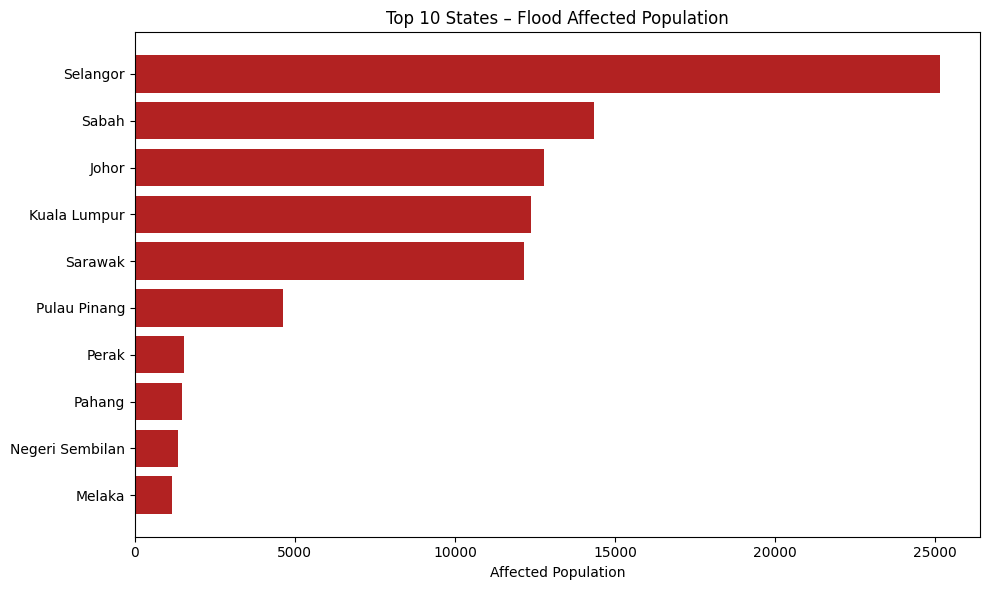

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Top10_Affected_Population_States.png


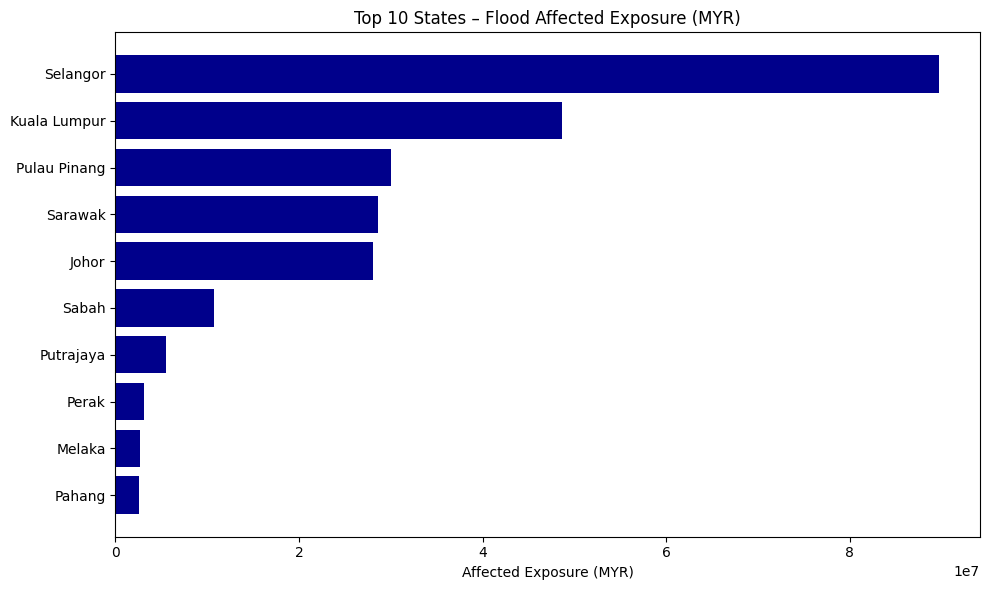

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Top10_Affected_Exposure_States.png


<Figure size 1000x900 with 0 Axes>

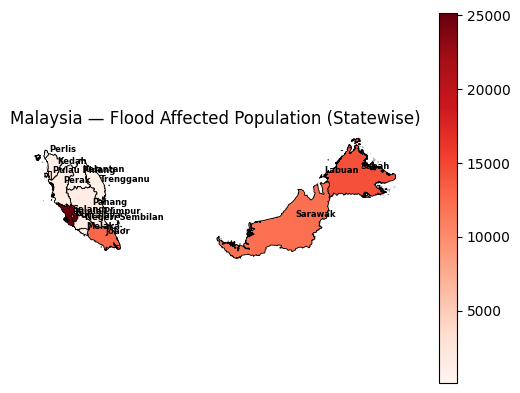

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Choropleth_Affected_Population.png


<Figure size 1000x900 with 0 Axes>

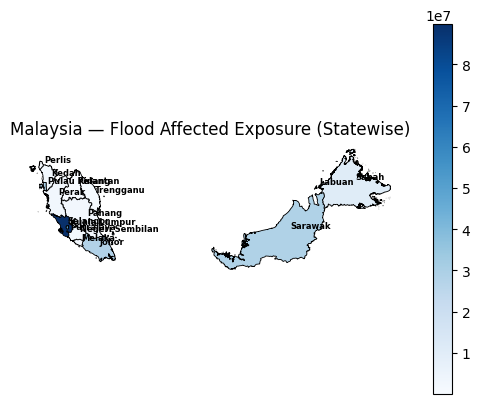

Saved: /content/drive/MyDrive/Abhinraj/AON Task/Choropleth_Affected_Exposure.png


In [ ]:
# ==========================================================
# TASK 3(b): FLOOD AFFECTED EXPOSURE PER STATE
# ==========================================================
# Inputs:
#  - Flood raster (0/1)
#  - Population-weighted exposure raster (Task 3a output)
#  - Admin-1 shapefile
#
# Output:
#  - Flood affected exposure raster
#  - CSV: Total affected exposure per State / FT
# ==========================================================

import geopandas as gpd
import rasterio
import numpy as np
from rasterstats import zonal_stats
import pandas as pd

# ------------------------------
# PATHS
# ------------------------------
base = "/content/drive/MyDrive/Abhinraj/AON Task/"

flood_raster = base + "flood_clipped_malaysia.tif"                 # from Task 2
exposure_raster = base + "population_weighted_exposure.tif"        # from Task 3a
states_shp = base + "gadm41_MYS_1.shp"

affected_exposure_raster = base + "affected_exposure_raster.tif"
output_csv = base + "statewise_affected_exposure_MYR.csv"


# ------------------------------
# 1 READ INPUT RASTERS
# ------------------------------
with rasterio.open(flood_raster) as f_src:
    flood = f_src.read(1)
    flood_meta = f_src.meta.copy()

with rasterio.open(exposure_raster) as e_src:
    exposure = e_src.read(1)

print("✔ Flood & Exposure rasters loaded")

# Safety cleaning
flood = np.where(flood == 1, 1, 0).astype("uint8")
exposure = np.where(exposure > 0, exposure, 0)


# ------------------------------
# 2 FLOOD × EXPOSURE → AFFECTED EXPOSURE RASTER
# ------------------------------
affected_exposure = np.where(flood == 1, exposure, 0)

flood_meta.update(dtype="float32", nodata=0)

with rasterio.open(affected_exposure_raster, "w", **flood_meta) as dst:
    dst.write(affected_exposure.astype("float32"), 1)

print("✔ Affected exposure raster created")


# ------------------------------
# 3 STATE-WISE SUM OF FLOODED EXPOSURE
# ------------------------------
states = gpd.read_file(states_shp).to_crs(flood_meta["crs"])

stats = zonal_stats(
    states,
    affected_exposure_raster,
    stats=["sum"],
    nodata=0
)

states["Affected_Exposure_MYR"] = [
    s["sum"] if s["sum"] is not None else 0
    for s in stats
]

result = states[["NAME_1", "Affected_Exposure_MYR"]]
result.columns = ["State_or_Federal_Territory", "Affected_Exposure_MYR"]

result.to_csv(output_csv, index=False)

print("✔ State-wise affected exposure calculated")
print(result)
# ==========================================================
# BONUS: RISK PROFILE VISUALIZATION
# ==========================================================
import matplotlib.pyplot as plt

pop_csv = base + "statewise_flood_affected_population.csv"
exp_csv = base + "statewise_affected_exposure_MYR.csv"

# Read data
pop_df = pd.read_csv(pop_csv)
exp_df = pd.read_csv(exp_csv)

# Merge with shapefile
states_vis = gpd.read_file(states_shp)
states_vis = states_vis.to_crs(flood_meta["crs"])

states_vis = states_vis.merge(
    pop_df,
    left_on="NAME_1",
    right_on="State_or_Federal_Territory",
    how="left"
)

states_vis = states_vis.merge(
    exp_df,
    left_on="NAME_1",
    right_on="State_or_Federal_Territory",
    how="left"
)

# ==========================================================
# 1 BAR CHART — TOP 10 STATES BY AFFECTED POPULATION
# ==========================================================
top_pop = pop_df.sort_values("Flood_Affected_Population", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_pop["State_or_Federal_Territory"], top_pop["Flood_Affected_Population"], color="firebrick")
plt.gca().invert_yaxis()
plt.title("Top 10 States – Flood Affected Population")
plt.xlabel("Affected Population")
plt.tight_layout()

pop_bar_path = base + "Top10_Affected_Population_States.png"
plt.savefig(pop_bar_path, dpi=300)
plt.show()

print("Saved:", pop_bar_path)


# ==========================================================
# 2 BAR CHART — TOP 10 STATES BY AFFECTED EXPOSURE
# ==========================================================
top_exp = exp_df.sort_values("Affected_Exposure_MYR", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_exp["State_or_Federal_Territory"], top_exp["Affected_Exposure_MYR"], color="darkblue")
plt.gca().invert_yaxis()
plt.title("Top 10 States – Flood Affected Exposure (MYR)")
plt.xlabel("Affected Exposure (MYR)")
plt.tight_layout()

exp_bar_path = base + "Top10_Affected_Exposure_States.png"
plt.savefig(exp_bar_path, dpi=300)
plt.show()

print("Saved:", exp_bar_path)


# ==========================================================
# 3 CHOROPLETH — STATEWISE AFFECTED POPULATION (WITH LABELS)
# ==========================================================
plt.figure(figsize=(10,9))
ax = states_vis.plot(
    column="Flood_Affected_Population",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True
)

# Add state labels
for idx, row in states_vis.iterrows():
    if pd.isna(row["Flood_Affected_Population"]):
        continue

    point = row.geometry.representative_point()  # safer than centroid
    ax.annotate(
        text=row["NAME_1"],
        xy=(point.x, point.y),
        xytext=(2,2),
        textcoords="offset points",
        fontsize=6,
        color="black",
        weight="bold"
    )

plt.title("Malaysia — Flood Affected Population (Statewise)")
plt.axis("off")

pop_map_path = base + "Choropleth_Affected_Population.png"
plt.savefig(pop_map_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pop_map_path)


# ==========================================================
# 4 CHOROPLETH — STATEWISE AFFECTED EXPOSURE (WITH LABELS)
# ==========================================================
plt.figure(figsize=(10,9))
ax = states_vis.plot(
    column="Affected_Exposure_MYR",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="black",
    legend=True
)

# Add state labels
for idx, row in states_vis.iterrows():
    if pd.isna(row["Affected_Exposure_MYR"]):
        continue

    point = row.geometry.representative_point()
    ax.annotate(
        text=row["NAME_1"],
        xy=(point.x, point.y),
        xytext=(2,2),
        textcoords="offset points",
        fontsize=6,
        color="black",
        weight="bold"
    )

plt.title("Malaysia — Flood Affected Exposure (Statewise)")
plt.axis("off")

exp_map_path = base + "Choropleth_Affected_Exposure.png"
plt.savefig(exp_map_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", exp_map_path)


In [ ]:
print("Flood shape:", flood.shape)
print("Exposure shape:", exposure.shape)

with rasterio.open(flood_raster) as f:
    print("Flood transform:", f.transform)

with rasterio.open(exposure_raster) as e:
    print("Exposure transform:", e.transform)

print("Unique flood values:", np.unique(flood))


Flood shape: (7245, 21849)
Exposure shape: (7245, 21849)
Flood transform: | 0.00, 0.00, 99.64|
| 0.00,-0.00, 7.36|
| 0.00, 0.00, 1.00|
Exposure transform: | 0.00, 0.00, 99.64|
| 0.00,-0.00, 7.36|
| 0.00, 0.00, 1.00|
Unique flood values: [0 1]


In [ ]:
pip install whitebox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.9 MB/s eta 0:00:00


Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.12/dist-packages/whitebox
Using DEM: /content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM.tif
./whitebox_tools --run="FillMissingData" --input='/content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM.tif' --output='/content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM_voidfilled.tif' --filter=11 --weight=2.0 --no_edges -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
thread 'main' panicked at whitebox-tools-app/src/main.rs:72:21:
No such file or directory (os error 2)
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace
✔ DEM voids filled → /content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM_voidfilled.tif
./whitebox_tools --run="FillDepressions" --dem='/content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM_void

In [ ]:
#Flood modelling assessment
# Task 5 ==========================================================
# HYDROLOGICAL DEM PROCESSING (SRTM 30m) — IMPROVED VERSION
# Steps:
#  0) Fill DEM voids / missing elevation values
#  1) Fill Sinks / Depressions
#  2) Generate D8 Flow Direction
#  3) Generate Flow Accumulation
#
# Base Folder:
# /content/drive/MyDrive/Abhinraj/AON Task/
# ==========================================================

# Install whitebox if not already installed
!pip install whitebox

import whitebox
wbt = whitebox.WhiteboxTools()

# -------------------------
# BASE DIRECTORY
# -------------------------
base = "/content/drive/MyDrive/Abhinraj/AON Task/"

# -------------------------
# FILE PATHS
# -------------------------
dem = base + "SRTM_river.tif"            # Raw DEM
void_filled_dem = base + "SRTM_30m_DEM_voidfilled.tif"
filled_dem = base + "filled_dem.tif"
flow_dir = base + "flow_direction_d8.tif"
flow_acc = base + "flow_accumulation_d8.tif"

print("Using DEM:", dem)

# -------------------------
# 0 Fill DEM Voids (Critical Step)
# -------------------------
# This fills missing elevation holes (NoData regions),
# ensuring hydrological continuity before routing.
wbt.fill_missing_data(
    i=dem,
    output=void_filled_dem,
    filter=11
)
print("✔ DEM voids filled →", void_filled_dem)

# -------------------------
# 1 Fill Sinks / Depressions
# -------------------------
wbt.fill_depressions(
    dem=void_filled_dem,
    output=filled_dem
)
print("✔ Sinks filled →", filled_dem)

# -------------------------
# 2 Flow Direction (D8)
# -------------------------
wbt.d8_pointer(
    dem=filled_dem,
    output=flow_dir
)
print("✔ Flow direction generated →", flow_dir)

# -------------------------
# 3 Flow Accumulation
# -------------------------
wbt.d8_flow_accumulation(
    filled_dem,
    flow_acc,
    out_type="cells"   # Number of contributing upstream cells
)

print("✔ Flow accumulation generated →", flow_acc)

print("\n🎯 DONE. All outputs saved in AON Task folder.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 5.5 MB/s eta 0:00:00
Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.12/dist-packages/whitebox
Using DEM: /content/drive/MyDrive/Abhinraj/AON Task/SRTM_river.tif
./whitebox_tools --run="FillMissingData" --input='/content/drive/MyDrive/Abhinraj/AON Task/SRTM_river.tif' --output='/content/drive/MyDrive/Abhinraj/AON Task/SRTM_30m_DEM_voidfilled.tif' --filter=11 --weight=2.0 --no_edges -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding edge-connected NoData values...
Interpolating data holes...
Interpolating data holes: 0%
Interpolating data holes: 1%
Interpolating data holes: 2%
Interpolating data holes: 3%
Interpolating data holes: 4%
Interpolating data holes: 5%
Interpolating data holes: 6%
Interpolating data holes: 7%
Int

In [ ]:
river_raster = base + "extracted_rivers.tif"

# ----------------------------------------------------
# Extract Streams from Flow Accumulation
# ----------------------------------------------------
wbt.extract_streams(
    flow_acc,
    river_raster,
    threshold=10000   # adjust until visually good
)

print("✔ Stream network extracted")

# ----------------------------------------------------
# Convert Raster Streams to Vector
# ----------------------------------------------------
river_vector = base + "extracted_rivers_raw.shp"

wbt.raster_streams_to_vector(
    streams=river_raster,
    d8_pntr=flow_dir,
    output=river_vector
)

print("✔ River network vector created")

# ----------------------------------------------------
# REPROJECT TO EPSG:32644  (WGS 84 / UTM Zone 44N)
# ----------------------------------------------------
import geopandas as gpd

river = gpd.read_file(river_vector)

# Set the original CRS to EPSG:4326 (WGS84), common for SRTM DEMs
river.set_crs(epsg=4326, inplace=True)

river_utm44 = river.to_crs(epsg=32644)

final_river_output = base + "extracted_rivers_utm44.shp"
river_utm44.to_file(final_river_output)

print("✔ Reprojected River Network Saved →", final_river_output)


./whitebox_tools --run="ExtractStreams" --flow_accum='/content/drive/MyDrive/Abhinraj/AON Task/flow_accumulation_d8.tif' --output='/content/drive/MyDrive/Abhinraj/AON Task/extracted_rivers.tif' --threshold='10000' -v --compress_rasters=False

*****************************
* Welcome to ExtractStreams *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%

In [ ]:
# ----------------------------------------------------
# STRAHLER STREAM ORDER
# ----------------------------------------------------
stream_order_raster = base + "stream_order_strahler.tif"

wbt.strahler_stream_order(
    d8_pntr = flow_dir,
    streams = river_raster,
    output = stream_order_raster
)

print("✔ Strahler Stream Order Raster Created:", stream_order_raster)
# ----------------------------------------------------
# Convert Stream Order Raster → Vector
# ----------------------------------------------------
stream_order_vector = base + "stream_order_strahler_raw.shp"

wbt.raster_streams_to_vector(
    streams = stream_order_raster,
    d8_pntr = flow_dir,
    output = stream_order_vector
)

print("✔ Strahler Stream Order Vector Created:", stream_order_vector)
import geopandas as gpd

gdf = gpd.read_file(stream_order_vector)

if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

gdf_utm = gdf.to_crs(epsg=32644)
gdf_utm.to_file(base + "stream_order_strahler_utm44.shp")

print("✔ Reprojected to UTM 44N")
stream_order_file = base + "stream_order_strahler_utm44.shp"

gdf_stream = gpd.read_file(stream_order_file)

print("\nFirst 6 Rows of Stream Order Attribute Table:\n")
print(gdf_stream.head(6))

./whitebox_tools --run="StrahlerStreamOrder" --d8_pntr='/content/drive/MyDrive/Abhinraj/AON Task/flow_direction_d8.tif' --streams='/content/drive/MyDrive/Abhinraj/AON Task/extracted_rivers.tif' --output='/content/drive/MyDrive/Abhinraj/AON Task/stream_order_strahler.tif' -v --compress_rasters=False

**********************************
* Welcome to StrahlerStreamOrder *
* Powered by WhiteboxTools       *
* www.whiteboxgeo.com            *
**********************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 

Files detected: 7
   Gauge-Discharge Data E-Managalam,1997-2017.csv
   Gauge-Discharge Data Gopurajapuram,1998-2017.csv
   Gauge-Discharge Data Chunchunkatte,1998-2016.csv
   Gauge-Discharge Data Akkihebbal,1998-2016.csv
   Gauge-Discharge Data Biligundulu,1971-2016.csv
   Gauge-Discharge Data Bendrehalli,2004-2016.csv
   Gauge-Discharge Data Annavasal,1998-2016.csv

Processing: Gauge-Discharge Data E-Managalam,1997-2017_
Total Years Available: 19
Monsoon Valid Years (filtered): 7
Rejected Years: [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2012, 2013, 2014, 2015, 2016]
⚠ WARNING: Less than 8 valid hydrological years (7 years) for Gauge-Discharge Data E-Managalam,1997-2017_. Results may be uncertain.


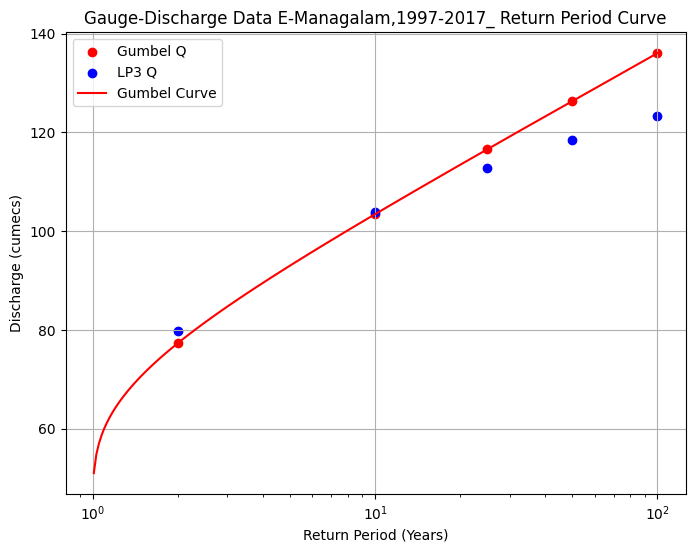

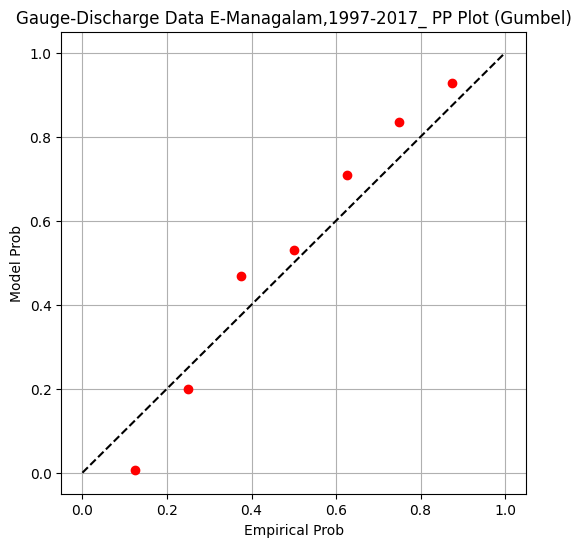

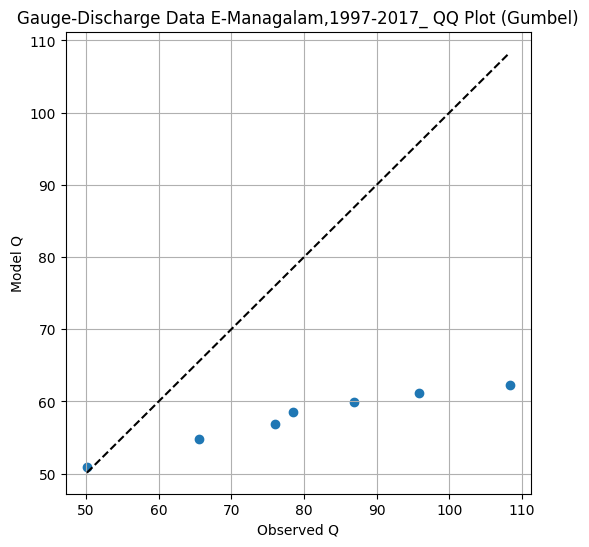


Processing: Gauge-Discharge Data Gopurajapuram,1998-2017_
Total Years Available: 18
Monsoon Valid Years (filtered): 0
Rejected Years: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Skipping station due to no valid Annual Maximum Series (AMS) data after monsoon filtering.

Processing: Gauge-Discharge Data Chunchunkatte,1998-2016_
Total Years Available: 9
Monsoon Valid Years (filtered): 6
Rejected Years: [2012, 2015, 2016]
⚠ WARNING: Less than 8 valid hydrological years (6 years) for Gauge-Discharge Data Chunchunkatte,1998-2016_. Results may be uncertain.


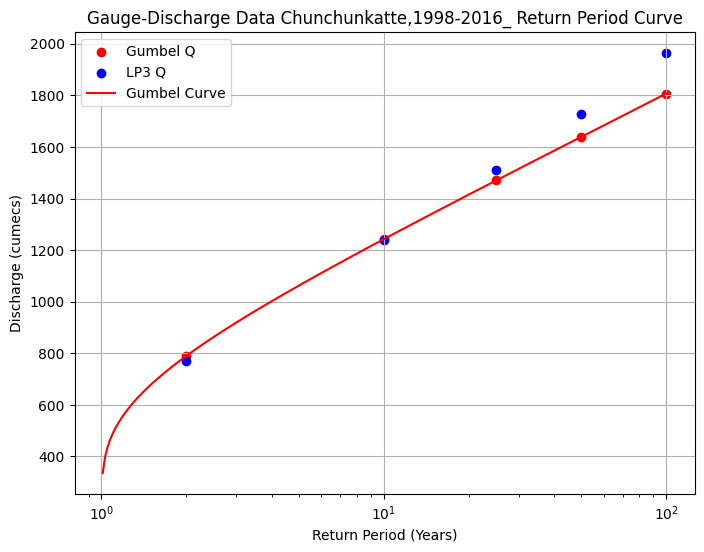

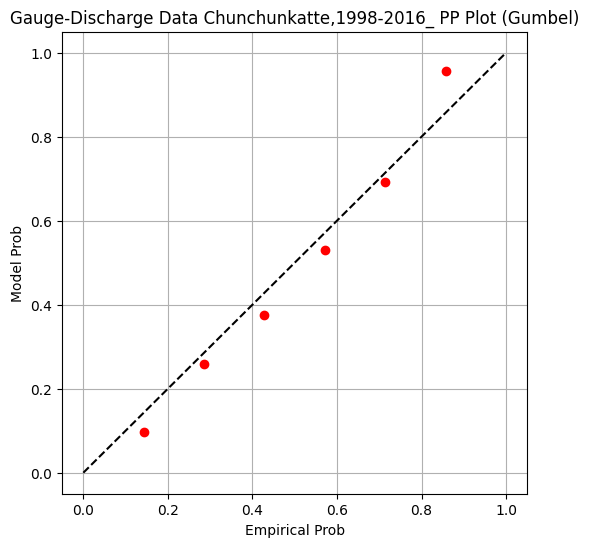

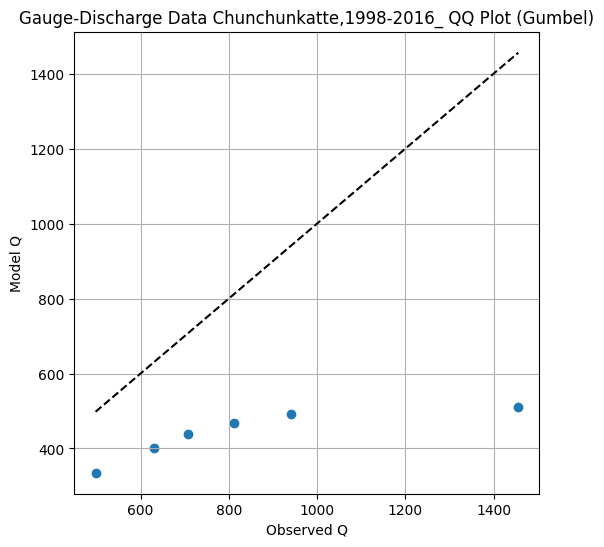


Processing: Gauge-Discharge Data Akkihebbal,1998-2016_
Total Years Available: 15
Monsoon Valid Years (filtered): 13
Rejected Years: [2015, 2016]


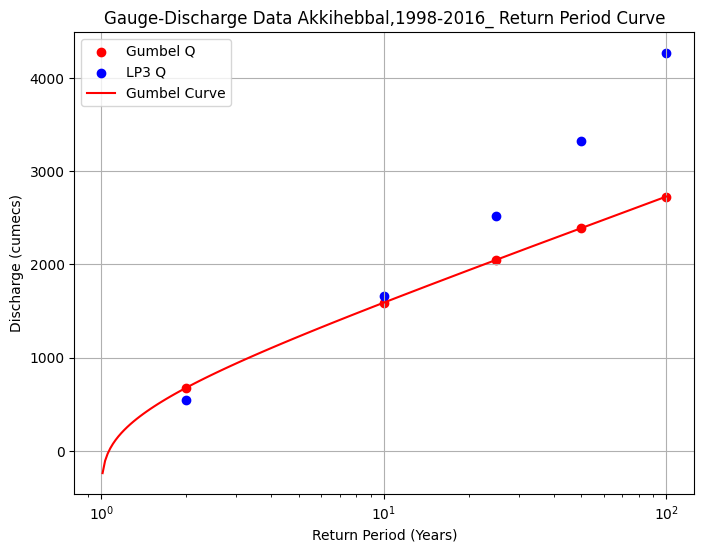

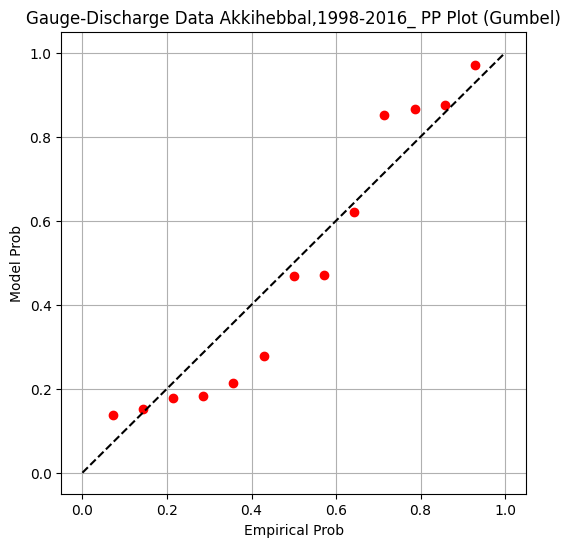

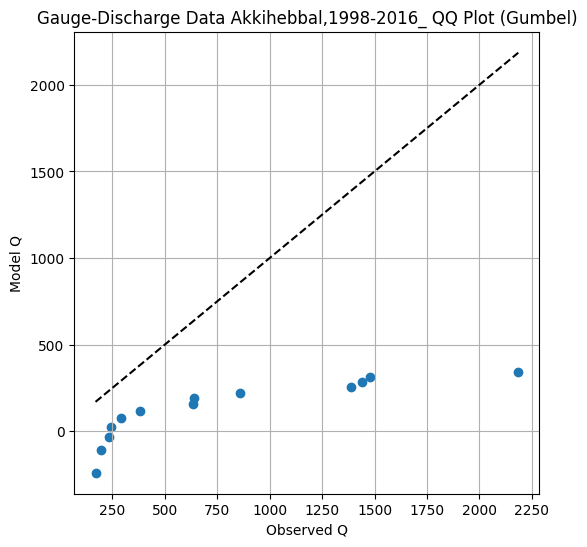


Processing: Gauge-Discharge Data Biligundulu,1971-2016_
Total Years Available: 46
Monsoon Valid Years (filtered): 43
Rejected Years: [1971, 2015, 2016]


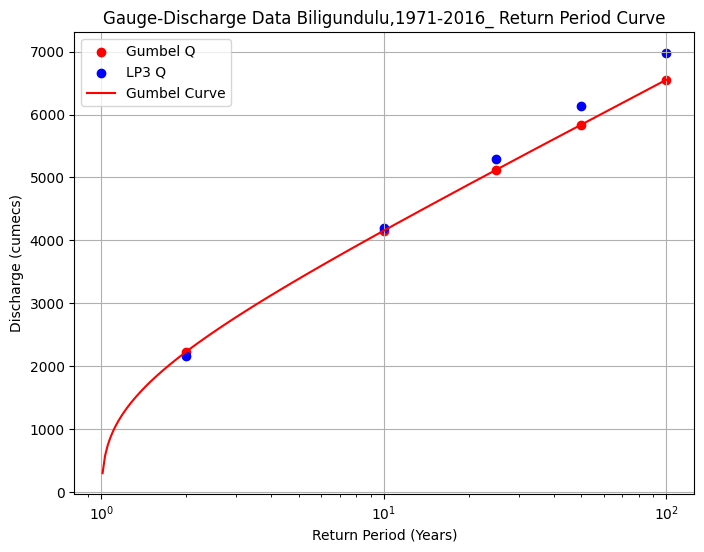

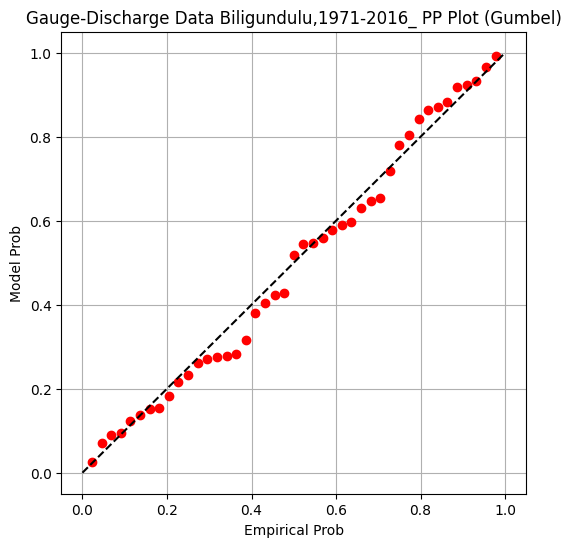

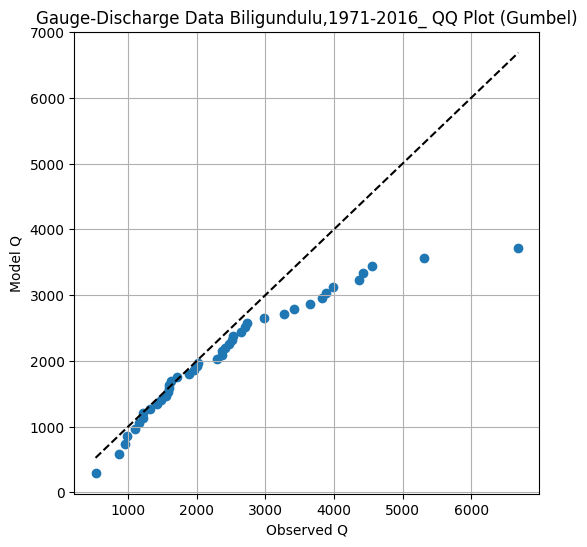


Processing: Gauge-Discharge Data Bendrehalli,2004-2016_
Total Years Available: 12
Monsoon Valid Years (filtered): 4
Rejected Years: [2005, 2007, 2010, 2012, 2013, 2014, 2015, 2016]
⚠ WARNING: Less than 8 valid hydrological years (4 years) for Gauge-Discharge Data Bendrehalli,2004-2016_. Results may be uncertain.


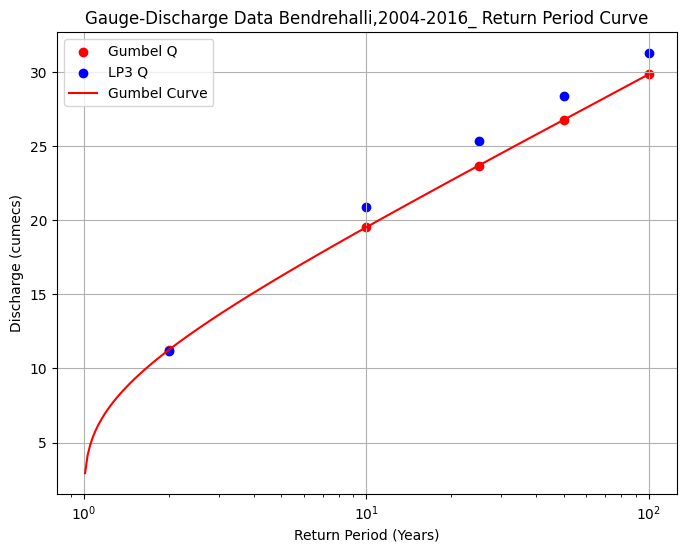

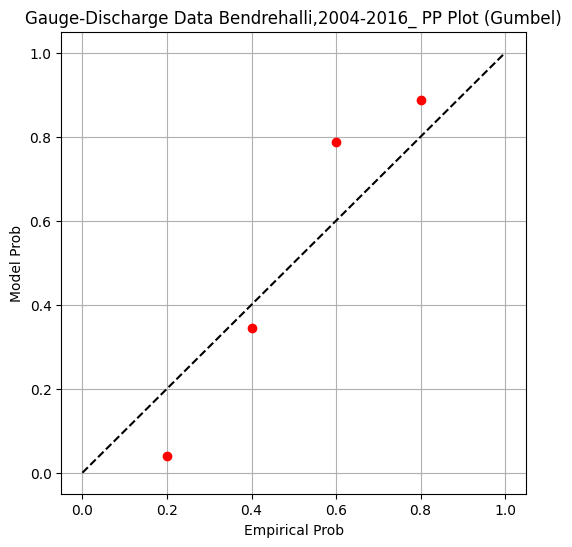

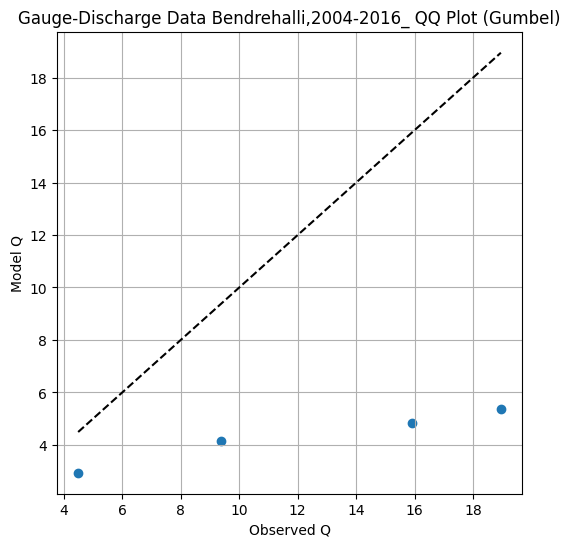


Processing: Gauge-Discharge Data Annavasal,1998-2016_
Total Years Available: 18
Monsoon Valid Years (filtered): 0
Rejected Years: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Skipping station due to no valid Annual Maximum Series (AMS) data after monsoon filtering.

FINAL SUMMARY
                                         Station  AMS Years Best Distribution  \
0    Gauge-Discharge Data E-Managalam,1997-2017_          7   Log Pearson III   
1  Gauge-Discharge Data Gopurajapuram,1998-2017_          0           No Data   
2  Gauge-Discharge Data Chunchunkatte,1998-2016_          6        Gumbel EV1   
3     Gauge-Discharge Data Akkihebbal,1998-2016_         13   Log Pearson III   
4    Gauge-Discharge Data Biligundulu,1971-2016_         43        Gumbel EV1   
5    Gauge-Discharge Data Bendrehalli,2004-2016_          4   Log Pearson III   
6      Gauge-Discharge Data Annavasal,1998-2016_          0           No Data   

   Se

In [ ]:
# ==========================================================
# TASK 6 — COMPLETE HYDROLOGY PACKAGE
# AMS + MONSOON VALIDITY FILTER
# Gumbel + LP3 + KS + AD + AIC + BIC
# CONFIDENCE + PP + QQ + RETURN PERIOD PLOT
# ==========================================================

import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt
from scipy.stats import kstest, anderson, pearson3, skew
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Base Directory
# -----------------------------
base = "/content/drive/MyDrive/Abhinraj/AON Task/"
files = glob.glob(base + "Gauge-Discharge/*.csv")

print("Files detected:", len(files))
for f in files:
    print("  ", os.path.basename(f))


# ==========================================================
# Helper Functions
# ==========================================================
def clean_discharge_csv(path):
    df = pd.read_csv(path, skiprows=2)
    df.columns = ["Date", "Type", "Gauge", "Discharge", "Obs"]

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")

    df = df.dropna().copy() # Use .copy() to prevent SettingWithCopyWarning
    df = df[df["Discharge"] > 0].copy() # Use .copy() to prevent SettingWithCopyWarning
    return df.sort_values("Date")


# ==========================================================
# MONSOON VALID YEAR FILTER
# ==========================================================
def filter_monsoon_valid_years(df):
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month

    valid_years = []
    rejected_years = []

    for yr, group in df.groupby("Year"):
        monsoon = group[group["Month"].isin([6,7,8,9,10])]

        if len(monsoon) == 0:
            rejected_years.append(yr)
            continue

        total_days = len(monsoon)
        expected_days = 153  # ~5 months

        completeness = total_days / expected_days

        if completeness >= 0.85:
            valid_years.append(yr)
        else:
            rejected_years.append(yr)

    df_valid = df[df["Year"].isin(valid_years)].copy() # Use .copy() to prevent SettingWithCopyWarning

    return df_valid, valid_years, rejected_years


# ==========================================================
# Annual Max Series
# ==========================================================
def annual_max_series(df):
    ams = df.groupby("Year")["Discharge"].max().reset_index()
    ams.columns = ["Year", "Q"]
    return ams


# ==========================================================
# Gumbel
# ==========================================================
def gumbel_params(data):
    # Handle empty data array case
    if len(data) == 0: return np.nan, np.nan

    mean = np.mean(data)
    sd = np.std(data)
    if sd == 0: # Avoid division by zero if all values are the same
        return mean, 0.00001 # a very small beta to avoid division by zero later

    beta = sd * np.sqrt(6) / np.pi
    mu = mean - 0.5772 * beta
    return mu, beta

def gumbel_q(mu,beta,T):
    if np.isnan(mu) or np.isnan(beta) or beta == 0: return np.nan
    return mu - beta * np.log(-np.log(1-1/T))

def gumbel_pdf(data,mu,beta):
    if len(data) == 0 or np.isnan(mu) or np.isnan(beta) or beta == 0: return np.array([])
    z = (data - mu)/beta
    return (1/beta)*np.exp(-(z + np.exp(-z)))


# ==========================================================
# Log Pearson III
# ==========================================================
def lp3_q(data,T):
    if len(data) == 0: return np.nan
    y = np.log10(data)
    mean = np.mean(y)
    sd = np.std(y)
    g = skew(y)
    # Check for valid T
    if T <= 1: # 1-1/T must be > 0 for ppf
        return np.nan
    kT = pearson3.ppf(1 - 1/T, g)
    return 10**(mean + kT*sd)

def lp3_pdf(data):
    if len(data) == 0: return np.array([])
    y = np.log10(data)
    mean = np.mean(y)
    sd = np.std(y)
    g = skew(y)
    # Check if data contains zero or negative values after filtering
    if np.any(data <= 0): return np.array([])
    return pearson3.pdf((y-mean)/sd,g) / (data*np.log(10))


# ==========================================================
# GOF + AIC BIC
# ==========================================================
def goodness_of_fit(data,dist):
    x = np.sort(data)
    n = len(x)

    if n == 0: # Crucial check to avoid ValueError with empty arrays
        return np.nan, np.nan

    if dist=="Gumbel":
        mu,beta = gumbel_params(data)
        if np.isnan(mu) or np.isnan(beta): return np.nan, np.nan
        cdf = np.exp(-np.exp(-(x-mu)/beta))
    else:
        y = np.log10(x)
        mean = np.mean(y)
        sd = np.std(y)
        g = skew(y)
        cdf = pearson3.cdf((np.log10(x)-mean)/sd,g)

    if cdf.size == 0 or np.any(np.isnan(cdf)): # Check for empty or NaN cdf
        return np.nan, np.nan

    ks = np.max(np.abs(cdf - np.arange(1,n+1)/n))

    ad_statistic = np.nan
    try:
        # Ensure log10(x) is valid before passing to anderson for 'norm'
        if dist != "Gumbel" and np.any(x <= 0): # Should be covered by clean_discharge_csv
            ad = anderson(np.full_like(x, np.nan), 'norm') # Pass NaN array to avoid error
        else:
            ad = anderson(x,'gumbel_r') if dist=="Gumbel" \
                else anderson(np.log10(x),'norm')
        ad_statistic = ad.statistic
    except Exception: # Catch potential errors from anderson test with small n or problematic data
        pass

    return ks,ad_statistic


def aic_bic(data,pdf,k):
    n = len(data)
    if n == 0 or pdf.size == 0 or np.any(np.isnan(pdf)): # Check for empty or NaN pdf
        return np.nan, np.nan
    logL = np.sum(np.log(pdf+1e-10))
    AIC = 2*k - 2*logL
    BIC = k*np.log(n) - 2*logL
    return AIC,BIC


# ==========================================================
# PROCESS STATIONS
# ==========================================================
summary = []

for file in files:

    station = os.path.basename(file).replace(".csv","_")
    print("\n====================================")
    print("Processing:", station)
    print("====================================")

    df = clean_discharge_csv(file)

    # --- MONSOON FILTER ---
    df_valid, valid_years, rejected_years = filter_monsoon_valid_years(df)

    print("Total Years Available:", df["Date"].dt.year.nunique())
    print("Monsoon Valid Years (filtered):", len(valid_years))
    print("Rejected Years:", rejected_years)

    ams = annual_max_series(df_valid)
    ams.to_csv(base+f"{station}_AMS.csv",index=False)

    data = ams["Q"].values
    n = len(data)

    if n == 0:
        print("Skipping station due to no valid Annual Maximum Series (AMS) data after monsoon filtering.")
        # Store placeholder results for this station
        summary.append([station, 0, "No Data", np.nan])
        continue # Skip the rest of the loop for this station

    if n < 8:
        print(f"⚠ WARNING: Less than 8 valid hydrological years ({n} years) for {station}. Results may be uncertain.")

    Ts = [2,10,25,50,100]

    # === GUMBEL ===
    mu,beta = gumbel_params(data)
    gumbel_vals = [gumbel_q(mu,beta,T) for T in Ts]
    gumbel_pdf_calculated = gumbel_pdf(data,mu,beta) # Renamed variable to avoid shadowing function
    gAIC,gBIC = aic_bic(data,gumbel_pdf_calculated,2)
    gKS,gAD = goodness_of_fit(data,"Gumbel")

    # === LP3 ===
    lp3_vals = [lp3_q(data,T) for T in Ts]
    lp3_pdf_calculated = lp3_pdf(data) # Renamed variable to avoid shadowing function
    lpAIC,lpBIC = aic_bic(data,lp3_pdf_calculated,3)
    lpKS,lpAD = goodness_of_fit(data,"LP3")

    # === BEST MODEL ===
    # Handle cases where GOF metrics might be NaN if calculations failed
    if np.isnan(gKS) or np.isnan(gAD) or np.isnan(gAIC) or np.isnan(gBIC):
        score_g = np.inf
    else:
        score_g = gKS+gAD+0.001*(gAIC+gBIC)

    if np.isnan(lpKS) or np.isnan(lpAD) or np.isnan(lpAIC) or np.isnan(lpBIC):
        score_lp = np.inf
    else:
        score_lp = lpKS+lpAD+0.001*(lpAIC+lpBIC)

    if score_lp < score_g:
        best = "Log Pearson III"
        Q100 = lp3_vals[-1]
    elif score_g < np.inf: # If Gumbel had valid score
        best = "Gumbel EV1"
        Q100 = gumbel_vals[-1]
    else:
        best = "N/A - No valid model"
        Q100 = np.nan

    # SAVE GOF
    pd.DataFrame({
        "Distribution":["Gumbel","LP3"],
        "KS":[gKS,lpKS],
        "AD":[gAD,lpAD],
        "AIC":[gAIC,lpAIC],
        "BIC":[gBIC,lpBIC]
    }).to_csv(base+f"{station}_GOF.csv",index=False)

    summary.append([station,n,best,Q100])


    # ======================================================
    # PLOTS
    # ======================================================
    # Only plot if valid Q100 was determined
    if not np.isnan(Q100):
        plt.figure(figsize=(8,6))
        Tr = [1/(1-p) for p in np.linspace(0.01,0.99,50) if p < 1] # Ensure 1-p is not zero
        g_curve = [gumbel_q(mu,beta,T) for T in Tr]

        plt.scatter(Ts,gumbel_vals,color='r',label="Gumbel Q")
        plt.scatter(Ts,lp3_vals,color='b',label="LP3 Q")
        if not np.any(np.isnan(g_curve)): # Plot Gumbel curve only if not all NaN
            plt.plot(Tr,g_curve,'r', label="Gumbel Curve")
        plt.xscale("log")
        plt.xlabel("Return Period (Years)")
        plt.ylabel("Discharge (cumecs)")
        plt.title(f"{station} Return Period Curve")
        plt.grid()
        plt.legend()
        plt.show()

        # PP Plot
        plt.figure(figsize=(6,6))
        x = np.sort(data)
        n = len(x)
        p = np.arange(1,n+1)/(n+1)
        # Ensure mu, beta are valid for g_pp calculation
        if not np.isnan(mu) and not np.isnan(beta) and beta != 0:
            g_pp = np.exp(-np.exp(-(x-mu)/beta))
        else:
            g_pp = np.full_like(p, np.nan) # Fill with NaN if parameters are invalid

        plt.plot(p,g_pp,'ro')
        plt.plot([0,1],[0,1],'k--')
        plt.title(f"{station} PP Plot (Gumbel)")
        plt.xlabel("Empirical Prob")
        plt.ylabel("Model Prob")
        plt.grid()
        plt.show()

        # QQ Plot
        plt.figure(figsize=(6,6))
        q_emp = np.sort(data)
        # Ensure g_curve is valid before slicing
        if not np.any(np.isnan(g_curve)) and n > 0:
            q_mod = np.sort(g_curve[:n])
        else:
            q_mod = np.full_like(q_emp, np.nan) # Fill with NaN if curve is invalid

        plt.scatter(q_emp,q_mod)
        plt.plot(q_emp,q_emp,'k--')
        plt.title(f"{station} QQ Plot (Gumbel)")
        plt.xlabel("Observed Q")
        plt.ylabel("Model Q")
        plt.grid()
        plt.show()
    else:
        print(f"Plots skipped for {station} due to insufficient valid data or model issues.")


# ==========================================================
# MASTER SUMMARY
# ==========================================================
summary_df = pd.DataFrame(
    summary,
    columns=["Station","AMS Years","Best Distribution","Selected Q100"]
)

summary_df.to_csv(base+"TASK6_Final_Frequency_Summary.csv",index=False)

print("\nFINAL SUMMARY")
print(summary_df)
